In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

import hubble_fit
from hubble_fit import z_agn_pivot
from hubble_fit import *

In [2]:
df_agn, df_pantheon, _sna_LogdetCov, _sna_L, _sna_Lower = hubble_fit.load_data("results/data/aug17/aug17_chisq_nobwb_carma21_qscpu_N20w4000s1000t8c4.h5", populate_sdss=False)


Loading quasar data...


Reading quasars from HDF5:  17%|█▋        | 162/960 [00:00<00:05, 153.38it/s]

Reading quasars from HDF5: 100%|██████████| 960/960 [00:05<00:00, 184.99it/s]


Number of quasars loaded: 960
Length of colin_df: 5136
Number with apparent_mag_2500 > 0: 4282
Length of merged DataFrame: 960
object_id not in merged: ['1406620', '1464676']
Number of quasars with 0 < z <= 1.0: 244
Number of quasars with z > 3: 25
Highest redshift quasar: 3.9210370051341137
Columns with NaNs: ['apparent_mag_g', 'apparent_mag_g_err', 'apparent_mag_i', 'apparent_mag_i_err', 'apparent_mag_r', 'apparent_mag_r_err', 'apparent_mag_u', 'apparent_mag_u_err', 'apparent_mag_z', 'apparent_mag_z_err', 'f_host_4200', 'apparent_mag_2500', 'apparent_mag_2500_err', 'alpha_lambda', 'alpha_lambda_err', 'redchi']
Cut on alpha_lambda: 44 objects removed
Cut on redchi: 5 objects removed
Cut on apparent_mag_2500: 174 objects removed
Cut on apparent_mag_i: 10 objects removed
Total objects removed by all cuts: 219
Number of quasars with 0 < z <= 1.0: 169
Number of dropped quasars with 0 < z <= 1.0: 75
Number of quasars with z > 3: 24
Final number of quasars: 741
Loading Pantheon+ supernova d

In [4]:
import hubble_fit
cosmo_model = 'Flatw0waCDM'
sampler, flat_samples, labels, mag_corr, logZ, logZerr = hubble_fit.run_mcmc_pipeline(df_agn, df_pantheon, cosmo_model=cosmo_model,
                                                                                      completeness=True, use_full_cov=True,
                                                                                      resume=True)


Running sampling with 12 parameters for cosmological model: Flatw0waCDM
Pivot point for x: 20.235424041748047
Scatter in m_2500 - m_i fit (std of residuals): 0.47
Using mag range: 16.00 to 26.00
log tau UV RF mean: 2.6763
log tau UV RF pivot (weighted): 2.5422
log sigma0 mean: -0.7574
log sigma0 pivot (weighted): -0.7668
bwb_beta pivot (weighted): nan
z mean: 1.603, calculated z pivot: 1.506
Checkpoint file: results/hubble/dynesty_checkpoint_Flatw0waCDM_joint_test.save


/opt/miniconda3/envs/jaxgpu/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:568: RuntimeWarning: invalid value encountered in multiply
  avg = avg_as_array = np.multiply(a, wgt,


Resuming from default checkpoint file: results/hubble/dynesty_checkpoint_Flatw0waCDM_joint_test.save
[Warning] Starting TEST run...


/opt/miniconda3/envs/jaxgpu/lib/python3.13/site-packages/dynesty/dynamicsampler.py:2046: RuntimeWarning: You tried to resume the run that has ended successfully.
This is not supported. No sampling was performed
  warnings.warn(



Bayesian evidence logZ = 1923.61 ± 0.46

Highest-weight (posterior) sample:
  idx: 6077
  logl: 1948.9477766477519
  weight: 0.0015683169373420422
  (preview) integrals[:10]: [0.03340764 0.04928498 0.11568892 0.03934499 0.03449907 0.05388778
 0.02498098 0.03016218 0.0632511  0.0472717 ]

Posterior (equal-weight) blob summaries:
  per-object mean (first 10): [0.03475517 0.04851408 0.10628084 0.03703665 0.03310794 0.05303696
 0.02461934 0.02905852 0.06261445 0.04594023]
  per-object median (first 10): [0.03483446 0.04853913 0.10616288 0.03703598 0.03313037 0.05307757
 0.02464218 0.02910636 0.06264971 0.04595675]

Dynesty results stats:
  samples shape: (7122, 12)
  blobs shape: (7122, 741)
  weights max: 0.0015683169373420422
  effective samples (ESS): 984.1712874435076
  resampled samples shape: (7122, 12)
  resampled blobs shape: (7122, 741)

Median parameters (equal-weight posterior):
[ 9.41502005e-03  8.73076434e-02 -1.92476160e+01 -2.18288066e+01
  4.92285168e+00 -1.49265346e+00 -1

/tmp/ipykernel_3876654/2574006633.py:246: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


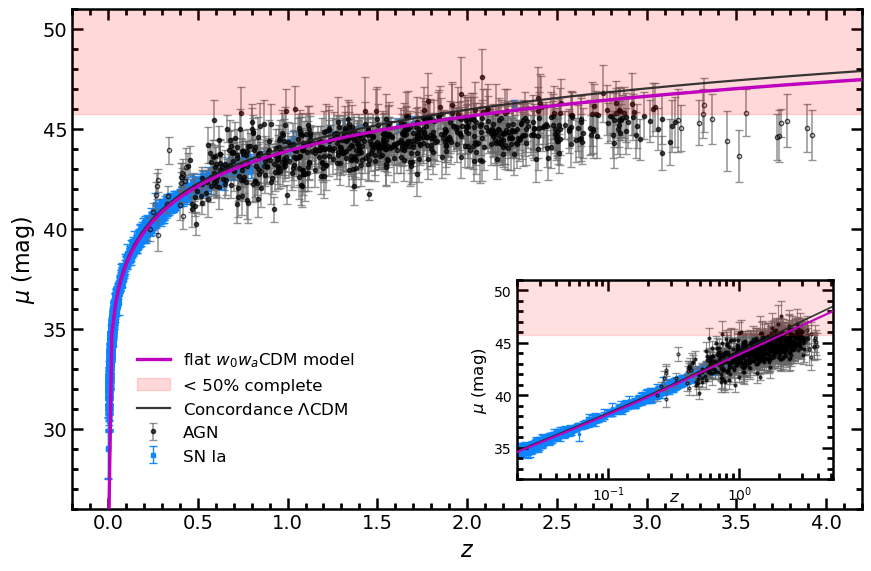

In [36]:
def plot_hubble(flat_samples, df_agn, df_pantheon, cosmo_model, z_agn_pivot, plot_path="plots/hubble/",
                show=False, completeness=True, show_true=False, verbose=True):
    """
    Hubble diagram (Pantheon+-style), vivid colors inlined:
      • Model line + 68% band in magenta ('m')
      • Intrinsic scatter as two magenta dotted lines
      • Survey magnitude limit as a teal shaded region
      • Concordance ΛCDM as solid black
      • SN Ia in bright blue
      • AGN points + error bars (same sizes/limits), solid if 0.44<=z<=3.16 else open
      • Inset shows the SAME elements as main panel
    Returns: residuals, mu_pred_median, mu_pred_std
    """
    import os
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes

    # --- Labels ---
    if   cosmo_model == 'FlatwCDM':      label = r"flat $w$CDM model"
    elif cosmo_model == 'Flatw0waCDM':   label = r"flat $w_0w_a$CDM model"
    elif cosmo_model == 'FlatLambdaCDM': label = r"flat $\Lambda$CDM model"
    else:
        raise ValueError("Invalid cosmology model.")

    # --- Thinning for speed ---
    n_samples = int(flat_samples.shape[0])
    thin_factor = max(1, n_samples // 500)
    flat_samples = flat_samples[::thin_factor]

    z_grid = np.linspace(1e-4, 5.2, 250)

    # --- Parameter bookkeeping ---
    _, model_labels, _ = get_model_params(cosmo_model)
    param_indices = {name: model_labels.index(name) for name in model_labels}

    # --- Cosmology band on grid ---
    if cosmo_model == 'FlatwCDM':
        mu_models = np.array([
            FlatwCDM(H0=s[param_indices['H0']], Om0=s[param_indices['Om0']], w0=s[param_indices['w0']]).distmod(z_grid).value
            for s in flat_samples
        ])
    elif cosmo_model == 'Flatw0waCDM':
        mu_models = np.array([
            FlatwpwaCDM(H0=s[param_indices['H0']], Om0=s[param_indices['Om0']],
                        wp=s[param_indices['wp']], wa=s[param_indices['wa']], zp=z_agn_pivot
                        ).distmod(z_grid).value
            for s in flat_samples
        ])
    else:  # FlatLambdaCDM
        mu_models = np.array([
            FlatLambdaCDM(H0=s[param_indices['H0']], Om0=s[param_indices['Om0']]).distmod(z_grid).value
            for s in flat_samples
        ])

    mu_model_16th   = np.percentile(mu_models, 16, axis=0)
    mu_model_median = np.percentile(mu_models, 50, axis=0)
    mu_model_84th   = np.percentile(mu_models, 84, axis=0)

    # Median params for uncertainties
    results = {key: np.percentile(flat_samples[:, i], [16, 50, 84])
               for i, key in enumerate(model_labels)}

    # --- Predicted AGN μ per object ---
    m_obs = df_agn['apparent_mag_2500'].values
    mu_pred_samples = np.array([
        m_obs - M_model_agn(
            s[param_indices['M0_agn']],
            s[param_indices['alpha_agn']],
            s[param_indices['beta_agn']],
            s[param_indices['gamma_agn']],
            df_agn['log_sigma_UV'].values,
            df_agn['log_tau_UV_RF'].values,
            df_agn['bwb_beta'].values
        ) for s in flat_samples
    ])

    mu_pred_median = np.percentile(mu_pred_samples, 50, axis=0)
    mu_pred_16th   = np.percentile(mu_pred_samples, 16, axis=0)
    mu_pred_84th   = np.percentile(mu_pred_samples, 84, axis=0)

    # Per-object uncertainty (for yerr)
    mu_pred_std = np.sqrt(
        df_agn['apparent_mag_2500_err'].values**2 +
        (0.055 * df_agn["z"].values)**2 +
        M_model_agn_err(
            results['M0_agn'][1],
            results['alpha_agn'][1],
            results['beta_agn'][1],
            results['gamma_agn'][1],
            df_agn['log_sigma_UV'].values,
            df_agn['log_sigma_UV_err'].values,
            df_agn['log_tau_UV_RF_err'].values,
            df_agn['bwb_beta_err'].values
        )**2
    )

    # Residuals (for outlier print only)
    mu_interp = np.interp(df_agn["z"].values, z_grid, mu_model_median)
    residuals = mu_pred_median - mu_interp

    # --- Simple equal-width z-bins (kept but not plotted by default) ---
    bins   = np.linspace(df_agn["z"].min(), df_agn["z"].max(), 24)
    binidx = np.digitize(df_agn["z"].values, bins)
    counts = np.array([np.sum(binidx == i) for i in range(1, len(bins))])
    valid  = counts >= 3

    def _bstat(arr, func):
        return np.array([func(arr[binidx == i]) if np.any(binidx == i) else np.nan
                         for i in range(1, len(bins))])[valid]

    binned_z            = _bstat(df_agn["z"].values, np.median)
    binned_mu_pred_mean = _bstat(mu_pred_median, np.mean)
    binned_mu_pred_sem  = np.array([
        np.std(mu_pred_median[binidx == i]) / max(1, np.sqrt(np.sum(binidx == i)))
        for i in range(1, len(bins))
    ])[valid]

    # ======== Plot ========
    fig, ax = plt.subplots(1, 1, figsize=(9, 6))
    ax.set_ylim(26, 51)
    ax.set_xlim(-0.2, 4.2)
    inset_ax = inset_axes(ax, width="40%", height="40%", loc="lower right", borderpad=1.5)

    # Solid vs open AGN markers by z (both main and inset)
    mask_in  = df_agn["z"].between(0.44, 3.16)
    mask_out = ~mask_in

    # ---------- Inset (log-z) with ALL elements ----------
    inset_ax.set_xscale('log')
    # AGN (inside)
    inset_ax.errorbar(
        df_agn["z"][mask_in], mu_pred_median[mask_in], yerr=mu_pred_std[mask_in],
        fmt='o', linestyle='none', markersize=2,
        mfc="black", mec="black",   # solid black markers
        ecolor="#666666", elinewidth=0.8,            
        alpha=0.7, zorder=1, label="AGN"
    )
    # AGN (outside, open)
    inset_ax.errorbar(df_agn["z"][mask_out], mu_pred_median[mask_out], yerr=mu_pred_std[mask_out],
                fmt='o', linestyle='none', markersize=2, mfc='none', mec="k", alpha=0.70,
                ecolor="#666666", elinewidth=0.8, zorder=1)

    # SN Ia
    inset_ax.errorbar(df_pantheon["zHD"], df_pantheon["MU_SH0ES"], yerr=df_pantheon["MU_SH0ES_ERR_DIAG"],
                      fmt='s', markersize=2, color="#0A84FF", linestyle='none', lw=0.8, alpha=0.95, zorder=0, label="SN Ia")
    # Model + band
    inset_ax.plot(z_grid, mu_model_median, color="m", lw=1.4, alpha=1.0, zorder=5, label=label)
    inset_ax.fill_between(z_grid, mu_model_16th, mu_model_84th, color="m", alpha=0.22, zorder=4)
    # Intrinsic scatter (dotted)
    # if 'log_f' in param_indices:
    #     sigma_int = float(np.sqrt(np.median(np.exp(2.0 * flat_samples[:, param_indices['log_f']]))))
    #     inset_ax.plot(z_grid, mu_model_median + sigma_int, color="m", ls=":", lw=1.2, alpha=0.9, label=r"Intrinsic scatter")
    #     inset_ax.plot(z_grid, mu_model_median - sigma_int, color="m", ls=":", lw=1.2, alpha=0.9)
    # Survey magnitude limit (shade above)
    if completeness:
        log_sigma0_med    = float(np.median(df_agn['log_sigma0'].values))
        log_tau_UV_RF_med = float(np.median(df_agn['log_tau_UV_RF'].values))
        bwb_med           = float(np.median(df_agn['bwb_beta'].values))
        M_med_grid = np.median([
            M_model_agn(
                s[param_indices['M0_agn']],
                s[param_indices['alpha_agn']],
                s[param_indices['beta_agn']],
                s[param_indices['gamma_agn']],
                log_sigma0_med * np.ones_like(z_grid),
                log_tau_UV_RF_med * np.ones_like(z_grid),
                bwb_med * np.ones_like(z_grid)
            ) for s in flat_samples
        ], axis=0)
        m_lim = 24.0
        mu_lim = m_lim - M_med_grid
        inset_ax.fill_between(np.linspace(-5, 10, len(mu_lim)), mu_lim, 60, color="red", alpha=0.12, zorder=2, label="< 50% complete")
    # Concordance
    mu_conc = FlatLambdaCDM(H0=70, Om0=0.3).distmod(z_grid).value
    inset_ax.plot(z_grid, mu_conc, color="#222222", lw=1.2, ls='-', alpha=0.9, label=r"Concordance $\Lambda$CDM")

    inset_ax.set_xlim(0.02, 5.2)
    inset_ax.set_ylim(32, 51)
    inset_ax.set_xlabel(r"$z$", fontsize=12, labelpad=-10)
    inset_ax.set_ylabel(r"$\mu$ (mag)", fontsize=12)
    inset_ax.tick_params(axis='both', which='major', labelsize=10)

    # ---------- Main plot with ALL elements ----------
    # AGN (inside)
    ax.errorbar(
        df_agn["z"][mask_in], mu_pred_median[mask_in], yerr=mu_pred_std[mask_in],
        fmt='o', linestyle='none', markersize=3,
        mfc="black", mec="black",   # solid black markers
        ecolor="#666666", elinewidth=1.1,            
        alpha=0.7, zorder=1, label="AGN"
    )
    # AGN (outside, open)
    ax.errorbar(df_agn["z"][mask_out], mu_pred_median[mask_out], yerr=mu_pred_std[mask_out],
                fmt='o', linestyle='none', markersize=3, mfc='none', mec="k", alpha=0.70,
                ecolor="#666666", elinewidth=1.1, zorder=1)

    # SN Ia
    ax.errorbar(df_pantheon["zHD"], df_pantheon["MU_SH0ES"], yerr=df_pantheon["MU_SH0ES_ERR_DIAG"],
                fmt='s', markersize=3, color="#0A84FF", linestyle='none', lw=1, alpha=0.95, zorder=0, label="SN Ia")

    # Model + 68% band
    ax.plot(z_grid, mu_model_median, color="m", lw=2.4, alpha=1.0, zorder=5, label=label)
    ax.fill_between(z_grid, mu_model_16th, mu_model_84th, color="m", alpha=0.25, zorder=4)

    # Intrinsic scatter (dotted)
    # if 'log_f' in param_indices:
    #     sigma_int = float(np.sqrt(np.median(np.exp(2.0 * flat_samples[:, param_indices['log_f']]))))
    #     ax.plot(z_grid, mu_model_median + sigma_int, color="m", ls=":", lw=2.0, alpha=0.9, label=r"Intrinsic scatter")
    #     ax.plot(z_grid, mu_model_median - sigma_int, color="m", ls=":", lw=2.0, alpha=0.9)

    # Survey magnitude limit (shade above)
    if completeness:
        # (Reuse mu_lim from inset block if desired; recompute for clarity)
        log_sigma0_med    = float(np.median(df_agn['log_sigma0'].values))
        log_tau_UV_RF_med = float(np.median(df_agn['log_tau_UV_RF'].values))
        bwb_med           = float(np.median(df_agn['bwb_beta'].values))
        M_med_grid = np.median([
            M_model_agn(
                s[param_indices['M0_agn']],
                s[param_indices['alpha_agn']],
                s[param_indices['beta_agn']],
                s[param_indices['gamma_agn']],
                log_sigma0_med * np.ones_like(z_grid),
                log_tau_UV_RF_med * np.ones_like(z_grid),
                bwb_med * np.ones_like(z_grid)
            ) for s in flat_samples
        ], axis=0)
        m_lim = 24.0
        mu_lim = m_lim - M_med_grid
        ax.fill_between(np.linspace(-5, 10, len(mu_lim)), mu_lim, 60, color="red", alpha=0.15, zorder=2, label="< 50% complete")

    # Concordance ΛCDM
    mu_conc = FlatLambdaCDM(H0=70, Om0=0.3).distmod(z_grid).value
    ax.plot(z_grid, mu_conc, color="#222222", lw=1.6, ls='-', alpha=0.9, label=r"Concordance $\Lambda$CDM")

    # Labels, ticks, legend
    ax.set_ylabel(r"$\mu$ (mag)")
    ax.set_xlabel(r"$z$")
    ax.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.22, 0.06), fontsize=12)

    for axi in (ax, inset_ax):
        axi.minorticks_on()
        axi.tick_params(axis='both', which='minor', direction='in', length=4, top=True, right=True, width=2)
        axi.tick_params(axis='both', which='major', direction='in', length=8, top=True, right=True)

    # Save/show
    fig.tight_layout()
    os.makedirs(plot_path, exist_ok=True)
    plt.savefig(os.path.join(plot_path, "hubble_diagram.png"))
    if show:
        plt.show()
    plt.close(fig)

    # Outlier report
    outlier_mask = np.abs(residuals) > 2
    if np.any(outlier_mask) and verbose:
        print("Outliers with residuals > 2:")
        for idx in np.where(outlier_mask)[0]:
            ra  = df_agn.iloc[idx].get('ra',  np.nan)
            dec = df_agn.iloc[idx].get('dec', np.nan)
            z   = df_agn.iloc[idx]['z']
            print(f"RA: {ra:.5f} | DEC: {dec:.5f} | z: {z:.3f} | Residual: {residuals[idx]:.2f}")

    return residuals, mu_pred_median, mu_pred_std

residuals, mu_pred_median, mu_pred_std = plot_hubble(flat_samples, df_agn, df_pantheon, z_agn_pivot=z_agn_pivot, cosmo_model=cosmo_model, show=True, verbose=False, show_true=False)

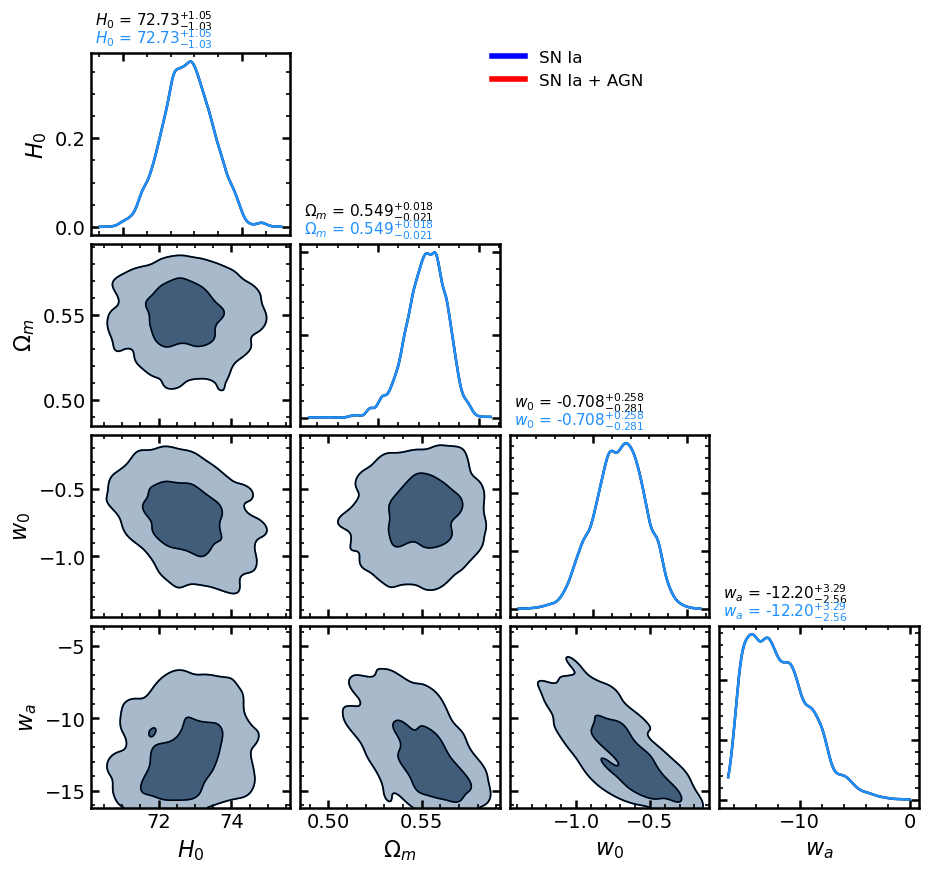

In [17]:
plot_cosmo_corner(flat_samples, flat_samples, cosmo_model=cosmo_model, z_agn_pivot=z_agn_pivot, plot_path="plots/hubble", show=True)

In [83]:
df_agn_sorted = df_agn.assign(mu_pred_std=mu_pred_std)
df_agn_sorted = df_agn_sorted[df_agn_sorted['mu_pred_std'] > 5].sort_values('mu_pred_std', ascending=False)
df_agn_sorted[['object_id', 'z', 'mu_pred_std']]

,object_id,z,mu_pred_std
78,1395656,1.900529,15.997955
154,1406124,1.685036,14.794409
297,1423342,0.693681,14.749796
163,1407986,2.138195,8.786025
215,1413889,2.504551,6.718891
503,1445049,2.276504,6.474745
34,1391845,1.187668,6.066265
203,1412204,1.342666,6.065583
616,1451194,1.268134,6.044926
363,1430274,1.233711,5.320571


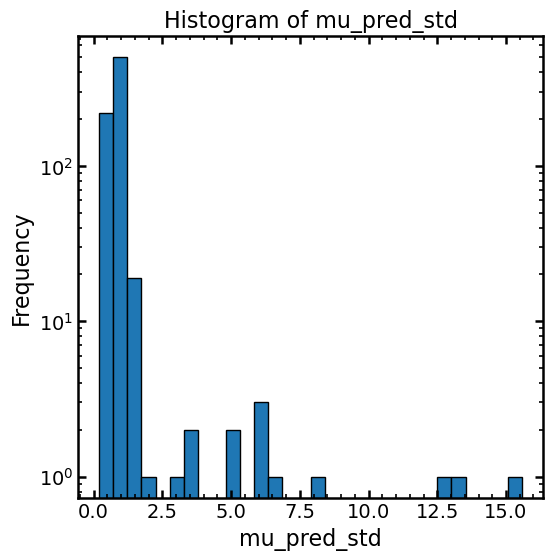

In [8]:
import matplotlib.pyplot as plt

plt.hist(mu_pred_std, bins=30, edgecolor='black')
plt.xlabel('mu_pred_std')
plt.ylabel('Frequency')
plt.yscale('log')
plt.title('Histogram of mu_pred_std')
plt.show()

,object_id,z
34,1391845,1.187668
78,1395656,1.900529
154,1406124,1.685036
163,1407986,2.138195
203,1412204,1.342666
215,1413889,2.504551
237,1416164,0.655224
297,1423342,0.693681
343,1428290,1.027927
363,1430274,1.233711


Reduced chi^2: 9.508


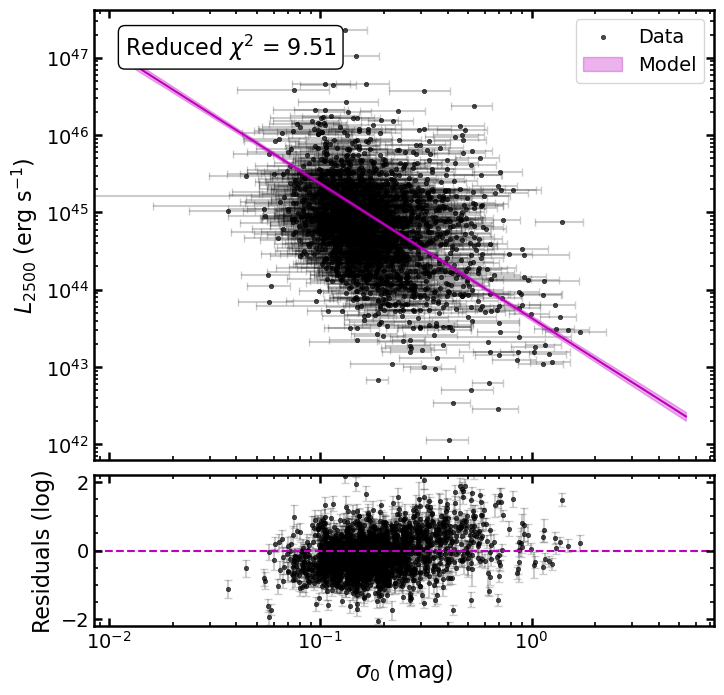

In [10]:
from hubble_plotting import plot_predicted_L2500_vs_sigmahat

plot_predicted_L2500_vs_sigmahat(flat_samples, df_agn, z_agn_pivot=z_agn_pivot, cosmo_model=cosmo_model, show=True)

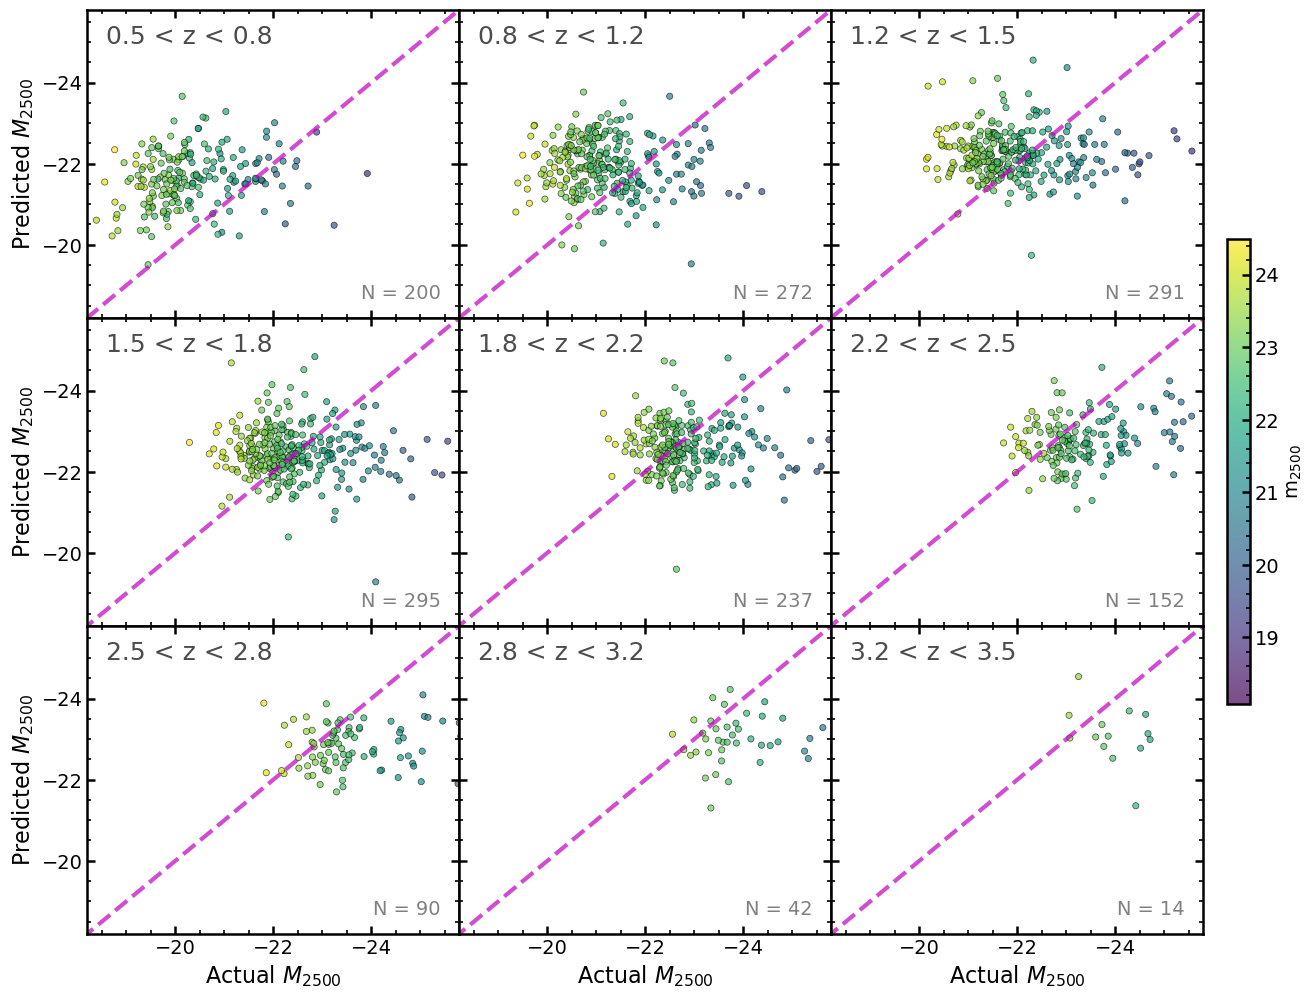

In [12]:
from hubble_plotting import plot_predicted_vs_actual_M2500

plot_predicted_vs_actual_M2500(flat_samples, df_agn, z_agn_pivot=z_agn_pivot, cosmo_model=cosmo_model, show=True)